In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [3]:
filename = 'output/flowVolume.csv'

# 读取CSV文件
data = pd.read_csv(filename)

# 提取时间和流量数据
time = data['time'].values # 0-23
flow_volume = data['flow volume'].values # 0-23小时对应的流量

# 在flow_volume后面加上12个0，表示24-35小时的流量为0
flow_trend = np.concatenate((flow_volume, np.zeros(12)))

data.head()

,time,flow volume
0,0,1.2
1,1,1.0
2,2,0.8
3,3,0.6
4,4,0.4


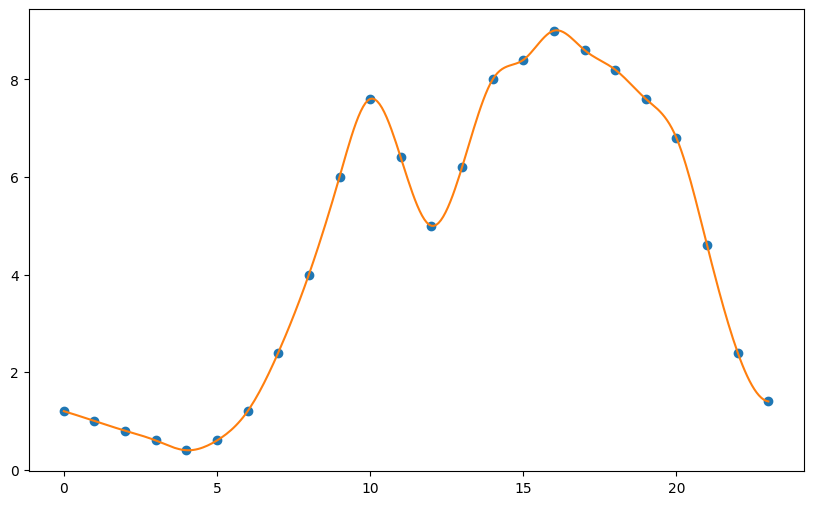

In [4]:
# 创建插值函数，用于生成光滑曲线
f = interp1d(time, flow_volume, kind='cubic', fill_value="extrapolate")

# 创建用于绘图的更密集的时间点
dense_time = np.linspace(time[0], time[-1], 300)

# 使用插值函数计算密集时间点的流量
dense_flow_volume = f(dense_time)

# 绘制原始数据点
plt.figure(figsize=(10, 6))
plt.plot(time, flow_volume, 'o', label='Original Data')

# 绘制拟合曲线
plt.plot(dense_time, dense_flow_volume, '-', label='Smooth Curve')

In [5]:
import json
import pandas as pd
import numpy as np
# 从文件读取
with open('output/data_6e.json', 'r') as f:
    path_data = json.load(f)
# print(path_data)
dist = pd.read_csv('output/dist_6e.csv',header=0,index_col=0)

weight = pd.read_csv('output/population_6e.csv',header=0,index_col=None) #每个出入口对应的城市人口
print(weight)

     e1   e2   e3   e4   e5   e6
0  2183  547  723  549  944  944


In [6]:
# 计算每个OD对的交互作用，目的是为了计算每个OD对的需求量权重

interaction = {}


for p in path_data: # 遍历每个OD对
    # Ensure all inputs are scalars
    source_weight = weight[path_data[p]['source']].values[0]  # 提取每个od对的源城市人口，作为需求源权重
    root_weight = weight[path_data[p]['root']].values[0]  # 提取每个od对的汇城市人口，作为需求汇权重
    distance = dist[path_data[p]['source']][path_data[p]['root']]  # 提取每个od对的距离，作为需求距离

    # Print scalar values
    print(source_weight, root_weight, distance)

    # Calculate interaction and assign it as a scalar value
    interaction[p] = source_weight * root_weight / distance**2
    
    # Print the scalar value of interaction for each path
    print(interaction[p])


2183 549 279
15.396346398427564
2183 944 340
17.826574394463666
2183 944 440
10.644380165289256
547 944 246
8.532751668980104
547 944 346
4.31327475024224
723 944 263
9.867310500368662
549 2183 279
15.396346398427564
944 2183 340
17.826574394463666
944 547 246
8.532751668980104
944 2183 440
10.644380165289256
944 547 346
4.31327475024224
944 723 263
9.867310500368662


In [7]:
import random
import numpy as np
import json

fL = {} #流量


# Normalize flow trend to obtain probabilities 按时间归一化
probabilities = [flow / sum(flow_trend) for flow in flow_trend]

# Assume interaction is predefined, sum_interaction represents the total sum of all interactions
sum_interaction = sum(interaction.values())

# Precompute base flows for fL, as they should remain constant across scenarios

f_base = {}

f_pt = {}

for p in path_data:  
    # 每个OD对的流量分配比例根据交互作用进行分配的比例，在这里就是每个O-D的流量占总流量的比例

    f_base[p] = interaction[p] / sum_interaction

    # Distribute flows across time periods
    for t in range(len(probabilities)):
        f_pt[p,t] = f_base[p]*probabilities[t]

print(sum(f_base.values()))  # 应该接近1，表示所有OD对的流量分配比例之和为1


# 在流量计算前添加检查
total_f_pt = sum(f_pt.values())
print(f"Total f_pt: {total_f_pt}")


0.9999999999999999
Total f_pt: 1.0000000000000004


In [8]:
sigma_ratio = 0.3  # cv
total_volume = 100
np.random.seed(1)

f_dict = {}

N = 6 # 初始soc等级数量   2，3，4，5 随机分配总量

# 为当前场景生成扰动后的权重（非负）
weights = []
index_list = []  # 保存 (n, p, t) 映射

for n in range(2, N):
    for p in path_data:
        for t in range(24):
            eps = np.random.normal(0, sigma_ratio) * f_pt[p, t]
            val = max(0.0, f_pt[p, t] + eps)
            weights.append(val)
            index_list.append((n,p,t))

weights = np.array(weights, dtype=float)


# 归一化为概率；极端情况下退化为均匀分布
if weights.sum() <= 0:
    prob = np.full_like(weights, 1.0 / len(weights))
else:
    prob = weights / weights.sum()

# 一次性整数分配，保证总量守恒
alloc = np.random.multinomial(total_volume, prob)

for idx, (n, p, t) in enumerate(index_list):
    f_dict[n,p,t] = int(alloc[idx])

# # 24-35 时段保持 0
# for n in range(2, N):
#     for p in path_data:
#         for t in range(24, 36):
#             f_dict[n,p,t] = 0
            

# 输出结果检查
check = sum(f_dict.values())
# print(check)

# for n in range(2,N ):
#     for t in range(24):
#         # print(f_dict[n,'p1',t])

print(f_dict)


{(2, 'p1', 0): 0, (2, 'p1', 1): 0, (2, 'p1', 2): 0, (2, 'p1', 3): 0, (2, 'p1', 4): 0, (2, 'p1', 5): 0, (2, 'p1', 6): 0, (2, 'p1', 7): 0, (2, 'p1', 8): 1, (2, 'p1', 9): 0, (2, 'p1', 10): 0, (2, 'p1', 11): 0, (2, 'p1', 12): 0, (2, 'p1', 13): 0, (2, 'p1', 14): 0, (2, 'p1', 15): 0, (2, 'p1', 16): 0, (2, 'p1', 17): 0, (2, 'p1', 18): 0, (2, 'p1', 19): 0, (2, 'p1', 20): 0, (2, 'p1', 21): 0, (2, 'p1', 22): 0, (2, 'p1', 23): 0, (2, 'p2', 0): 0, (2, 'p2', 1): 0, (2, 'p2', 2): 0, (2, 'p2', 3): 0, (2, 'p2', 4): 0, (2, 'p2', 5): 0, (2, 'p2', 6): 0, (2, 'p2', 7): 0, (2, 'p2', 8): 1, (2, 'p2', 9): 1, (2, 'p2', 10): 0, (2, 'p2', 11): 0, (2, 'p2', 12): 0, (2, 'p2', 13): 0, (2, 'p2', 14): 0, (2, 'p2', 15): 0, (2, 'p2', 16): 1, (2, 'p2', 17): 0, (2, 'p2', 18): 1, (2, 'p2', 19): 0, (2, 'p2', 20): 0, (2, 'p2', 21): 1, (2, 'p2', 22): 0, (2, 'p2', 23): 0, (2, 'p3', 0): 0, (2, 'p3', 1): 0, (2, 'p3', 2): 0, (2, 'p3', 3): 0, (2, 'p3', 4): 0, (2, 'p3', 5): 0, (2, 'p3', 6): 0, (2, 'p3', 7): 0, (2, 'p3', 8): 0, (2

In [9]:
# Convert to JSON format and save the results
f_json = {str(k): int(v) for k, v in f_dict.items()}

with open(f'6e_flow_{total_volume}_{sigma_ratio:.2f}.json', 'w') as f:
    json.dump(f_json, f)
